# Primary Model Evaluation (Mean + FPR@20%)

This notebook is the **primary evaluation** for all trained autoencoders using:
- **Score method:** mean reconstruction error
- **Thresholding:** FPR-controlled threshold on normal validation scores
- **Target FPR:** 20%

This avoids label-optimized threshold bias (e.g., Youden on mixed eval labels) and keeps one consistent policy across models.

## Evaluation order
1. ECNN-AE Optimized
2. CNN-AE Large
3. CNN-AE Augmented
4. CNN-AE
5. ResNet-AE
6. ResNet-AE Finetuned (partial)

In [1]:
# Colab / local environment setup
import os
import sys
import subprocess
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    REPO_ROOT = Path('/content/symAD-ECNN')
    if not REPO_ROOT.exists():
        subprocess.check_call(['git', 'clone', 'https://github.com/RifaDeen/symAD-ECNN.git', str(REPO_ROOT)])
else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT != REPO_ROOT.parent:
        if (REPO_ROOT / 'README.md').exists() and (REPO_ROOT / 'notebooks').exists():
            break
        REPO_ROOT = REPO_ROOT.parent

EVALS_DIR = REPO_ROOT / 'notebooks' / 'evals'
for p in [REPO_ROOT, EVALS_DIR, EVALS_DIR / 'ecnn_thresholding']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

print(f'IN_COLAB: {IN_COLAB}')
print(f'REPO_ROOT: {REPO_ROOT}')
print(f'EVALS_DIR: {EVALS_DIR}')

Mounted at /content/drive
IN_COLAB: True
REPO_ROOT: /content/symAD-ECNN
EVALS_DIR: /content/symAD-ECNN/notebooks/evals


In [2]:
# Imports
import json
import shutil
import zipfile
import importlib.util
from glob import glob
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc

from metrics_utils import threshold_from_normal_scores, compute_full_metrics

# Ensure e2cnn is installed in the active kernel before importing ECNN loader
if importlib.util.find_spec('e2cnn') is None:
    print('Installing e2cnn in active environment...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'e2cnn'])

from ecnn_model_loader import get_model_for_inference

plt.style.use('seaborn-v0_8')
print('All imports ready.')

Installing e2cnn in active environment...
All imports ready.


In [3]:
# Paths, output folders, and model configuration
if IN_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/symAD-ECNN')
    OUTPUT_ROOT = PROJECT_ROOT / 'evaluations'
else:
    PROJECT_ROOT = REPO_ROOT
    OUTPUT_ROOT = REPO_ROOT / 'results' / 'primary_evaluations'

DATA_ROOT = PROJECT_ROOT / 'data'
MODELS_ROOT = PROJECT_ROOT / 'models' / 'saved_models'

PRIMARY_NAME = 'primary_mean_fpr20'
TABLE_DIR = OUTPUT_ROOT / 'tables' / PRIMARY_NAME
FIG_DIR = OUTPUT_ROOT / 'figures' / PRIMARY_NAME
JSON_DIR = OUTPUT_ROOT / 'json' / PRIMARY_NAME
for d in [TABLE_DIR, FIG_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_SCORE_METHOD = 'mean'
TARGET_FPR = 0.20
TARGET_BATCH_SIZE = 16  # parity with thresholding notebook
# Scoring/thresholding defaults to match the thresholding experiment notebook
USE_BRAIN_MASK_FOR_SCORING = True
MIN_BRAIN_PIXELS = 50
FIXED_ERROR_MODE = 'squared'
CLASS_NAMES = ['Normal', 'Anomaly']

# Match ECNN training notebook turbo loader paths
BASE_DIR = DATA_ROOT
LOCAL_DIR = Path('/content/local_data') if IN_COLAB else (REPO_ROOT / '.local_data')

ZIPS = {
    'train': BASE_DIR / 'train_fast.zip',
    'val':   BASE_DIR / 'val_fast.zip',
    'test':  BASE_DIR / 'test_fast.zip',
}

IXI_TRAIN_PATH = LOCAL_DIR / 'train'
IXI_VAL_PATH = LOCAL_DIR / 'val'
BRATS_PATH = LOCAL_DIR / 'test'

# Wider checkpoint search roots (thresholding-style: repo + drive/local project)
CHECKPOINT_SEARCH_ROOTS = [
    PROJECT_ROOT / 'models' / 'saved_models',
    REPO_ROOT / 'models' / 'saved_models',
    PROJECT_ROOT / 'models',
    REPO_ROOT / 'models',
]
CHECKPOINT_SEARCH_ROOTS = [p for p in CHECKPOINT_SEARCH_ROOTS if p.exists()]

MODEL_CONFIGS = [
    {
        'key': 'ecnn_opt',
        'display_name': 'ECNN-AE (Optimized)',
        'model_type': 'ecnn',
        'checkpoint_dirs': ['ecnn_optimized', '.'],
        'checkpoint_patterns': ['ecnn_optimized_best.pth', 'ecnn_best.pth', '*ecnn*optimized*best*.pth', '*ecnn*best*.pth'],
    },
    {
        'key': 'cnn_large',
        'display_name': 'CNN-AE Large',
        'model_type': 'cnn_large',
        'checkpoint_dirs': ['cnn_ae_large'],
        'checkpoint_patterns': ['cnn_large_best.pth', '*cnn*large*best*.pth'],
    },
    {
        'key': 'cnn_aug',
        'display_name': 'CNN-AE Augmented',
        'model_type': 'cnn_base',
        'checkpoint_dirs': ['cnn_ae_augmented'],
        'checkpoint_patterns': ['cnn_aug_best.pth', '*cnn*aug*best*.pth'],
    },
    {
        'key': 'cnn_base',
        'display_name': 'CNN-AE',
        'model_type': 'cnn_base',
        'checkpoint_dirs': ['cnn_ae'],
        'checkpoint_patterns': ['cnn_best.pth', '*cnn*best*.pth'],
    },
    {
        'key': 'resnet_ae',
        'display_name': 'ResNet-AE',
        'model_type': 'resnet_frozen',
        'checkpoint_dirs': ['resnet_ae'],
        'checkpoint_patterns': ['resnet_best.pth', '*resnet*best*.pth'],
    },
    {
        'key': 'resnet_ft',
        'display_name': 'ResNet-AE Finetuned (partial)',
        'model_type': 'resnet_finetuned_partial',
        'checkpoint_dirs': ['resnet_finetuned_partial', 'resnet_finetuned_full', 'resnet_finetuned_none'],
        'checkpoint_patterns': ['resnet_best.pth', '*resnet*best*.pth'],
    },
]

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'MODELS_ROOT: {MODELS_ROOT}')
print(f'TABLE_DIR: {TABLE_DIR}')
print(f'FIG_DIR: {FIG_DIR}')
print(f'JSON_DIR: {JSON_DIR}')
print(f'BATCH_SIZE: {TARGET_BATCH_SIZE}')
print('Checkpoint search roots:')
for root in CHECKPOINT_SEARCH_ROOTS:
    print(f'  - {root}')

PROJECT_ROOT: /content/drive/MyDrive/symAD-ECNN
DATA_ROOT: /content/drive/MyDrive/symAD-ECNN/data
MODELS_ROOT: /content/drive/MyDrive/symAD-ECNN/models/saved_models
TABLE_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/primary_mean_fpr20
FIG_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20
JSON_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/json/primary_mean_fpr20
BATCH_SIZE: 16
Checkpoint search roots:
  - /content/drive/MyDrive/symAD-ECNN/models/saved_models
  - /content/symAD-ECNN/models/saved_models
  - /content/drive/MyDrive/symAD-ECNN/models
  - /content/symAD-ECNN/models


In [4]:
# Shared model classes + helper functions
from model_defs import CNNAutoencoder, LargeCNNAutoencoder, ResNetAutoencoder
from eval_common import (
    find_files,
    extract_zip,
    get_state_dict as get_state_dict_common,
    compute_reconstruction_errors,
)

class SliceDataset(Dataset):
    def __init__(self, files: List[Path], mode: str = 'grayscale'):
        self.files = files
        self.mode = mode
        self.resnet_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.files)

    def _load_slice(self, path: Path) -> np.ndarray:
        if path.suffix.lower() == '.npy':
            arr = np.load(path)
        else:
            arr = np.array(Image.open(path).convert('L')).astype(np.float32) / 255.0
        arr = arr.astype(np.float32)
        if arr.max() > 1.0:
            arr = arr / 255.0
        if arr.ndim == 3:
            arr = arr.squeeze()
        return arr

    def __getitem__(self, idx):
        arr = self._load_slice(self.files[idx])
        gray = torch.from_numpy(arr).float().unsqueeze(0)
        if gray.shape[-2:] != (128, 128):
            gray = F.interpolate(gray.unsqueeze(0), size=(128, 128), mode='bilinear', align_corners=False).squeeze(0)

        if self.mode == 'resnet':
            img_uint8 = (gray.squeeze(0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
            rgb = np.stack([img_uint8, img_uint8, img_uint8], axis=-1)
            inp = self.resnet_transform(rgb)
            tgt = gray
            return inp, tgt

        return gray, gray

def check_turbo_zips(zips: Dict[str, Path]):
    missing = [str(p) for p in zips.values() if not p.exists()]
    if missing:
        raise FileNotFoundError(
            'Missing turbo zip files. Run training/turbo prep first. Missing: ' + ', '.join(missing)
        )


def resolve_checkpoint_path(cfg: Dict) -> Path:
    # Thresholding-style strategy: scan multiple roots + recursive fallback
    candidates: List[Path] = []

    for root in CHECKPOINT_SEARCH_ROOTS:
        for sub in cfg['checkpoint_dirs']:
            base = root if sub == '.' else (root / sub)
            if not base.exists():
                continue
            for pattern in cfg['checkpoint_patterns']:
                matches = sorted(p for p in base.rglob(pattern) if p.is_file())
                candidates.extend(matches)

    if not candidates:
        for root in CHECKPOINT_SEARCH_ROOTS:
            for pattern in cfg['checkpoint_patterns']:
                matches = sorted(p for p in root.rglob(pattern) if p.is_file())
                candidates.extend(matches)

    deduped = []
    seen = set()
    for p in candidates:
        sp = str(p)
        if sp in seen:
            continue
        seen.add(sp)
        deduped.append(p)

    if not deduped:
        raise FileNotFoundError(
            f"No checkpoint found for {cfg.get('display_name', cfg.get('key', 'model'))} "
            f"under roots: {[str(r) for r in CHECKPOINT_SEARCH_ROOTS]}"
        )

    deduped = sorted(
        deduped,
        key=lambda p: (('best' not in p.name.lower()), -p.stat().st_mtime),
    )
    return deduped[0]


def load_model_for_config(cfg: Dict, device: str):
    ckpt_path = resolve_checkpoint_path(cfg)

    if cfg['model_type'] == 'ecnn':
        try:
            model, _ = get_model_for_inference(ckpt_path, device)
        except ImportError as e:
            if 'e2cnn' not in str(e).lower():
                raise
            print('e2cnn missing at runtime while loading ECNN; installing and retrying...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'e2cnn'])
            from ecnn_model_loader import get_model_for_inference as _get_model_for_inference
            model, _ = _get_model_for_inference(ckpt_path, device)
        model.eval()
        return model, ckpt_path

    checkpoint = torch.load(ckpt_path, map_location=device)
    state_dict = get_state_dict_common(checkpoint)

    if cfg['model_type'] == 'cnn_large':
        latent_dim = int(state_dict['fc_encode.weight'].shape[0]) if 'fc_encode.weight' in state_dict else 512
        model = LargeCNNAutoencoder(latent_dim=latent_dim)
    elif cfg['model_type'] == 'cnn_base':
        latent_dim = int(state_dict['fc_encode.weight'].shape[0]) if 'fc_encode.weight' in state_dict else 256
        model = CNNAutoencoder(latent_dim=latent_dim)
    elif cfg['model_type'] == 'resnet_frozen':
        model = ResNetAutoencoder(finetune_strategy='none')
    elif cfg['model_type'] == 'resnet_finetuned_partial':
        model = ResNetAutoencoder(finetune_strategy='partial')
    else:
        raise ValueError(f"Unsupported model type: {cfg['model_type']}")

    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model, ckpt_path


def compute_errors(model: nn.Module, dataloader: DataLoader, device: str, use_brain_mask: bool = True, min_brain_pixels: int = 50, error_mode: str = 'squared') -> np.ndarray:
    compute_reconstruction_errors._error_mode_default = error_mode
    compute_reconstruction_errors._use_brain_mask_default = use_brain_mask
    compute_reconstruction_errors._min_brain_pixels_default = min_brain_pixels
    return compute_reconstruction_errors(model, dataloader, device, desc='Computing reconstruction errors')


print('Shared model imports + helper definitions ready.')

Shared model imports + helper definitions ready.


In [ ]:
# Parity override: use threshold-notebook style per-slice scoring in primary run
@torch.no_grad()
def compute_errors(
    model: nn.Module,
    dataloader: DataLoader,
    device: str,
    use_brain_mask: bool = True,
    min_brain_pixels: int = 50,
    error_mode: str = 'squared',
) -> np.ndarray:
    model.eval()
    scores: List[float] = []

    if error_mode not in {'squared', 'abs'}:
        raise ValueError(f"Unsupported error_mode: {error_mode}")

    for x, y in tqdm(dataloader, desc='Computing reconstruction errors', leave=False):
        x = x.to(device)
        y = y.to(device)
        recon = model(x)

        # Thresholding notebook parity: error against model input when shapes match.
        # For models like ResNet-AE (RGB input -> gray output), fallback to target tensor.
        ref = x if tuple(recon.shape) == tuple(x.shape) else y

        diff = ref - recon
        err_map = diff.abs() if error_mode == 'abs' else diff.pow(2)

        if not use_brain_mask:
            batch_scores = err_map.view(err_map.size(0), -1).mean(dim=1)
            scores.extend(batch_scores.detach().cpu().numpy().tolist())
            continue

        for i in range(err_map.size(0)):
            sample_err = err_map[i]
            if sample_err.dim() == 3:
                sample_err = sample_err[0]

            # Thresholding parity mask: non-zero brain-like pixels.
            # Use the same reference tensor used for error-map construction.
            ref_slice = ref[i]
            if ref_slice.dim() == 3:
                ref_slice = ref_slice[0]
            brain_mask = (ref_slice > 0.01)

            if int(brain_mask.sum().item()) < int(min_brain_pixels):
                continue

            score = sample_err[brain_mask].mean()
            scores.append(float(score.detach().cpu().item()))

    return np.asarray(scores, dtype=np.float32)

print('Primary scoring override active: threshold-notebook parity mode.')

Using device: cuda
Extracting turbo datasets to local disk...
  train: /content/drive/MyDrive/symAD-ECNN/data/train_fast.zip -> /content/local_data/train
  val: /content/drive/MyDrive/symAD-ECNN/data/val_fast.zip -> /content/local_data/val
  test: /content/drive/MyDrive/symAD-ECNN/data/test_fast.zip -> /content/local_data/test
Train files (IXI train): 33078
Normal files (IXI val): 3652
Anomaly files (BraTS test): 7794

=== Evaluating: ECNN-AE (Optimized) ===
Detected ECNNAutoencoderV3 checkpoint. Using latent_dim=1024.


/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


Model weights loaded from: /content/drive/MyDrive/symAD-ECNN/models/saved_models/copy_ecnn_optimized/ecnn_optimized_best.pth


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

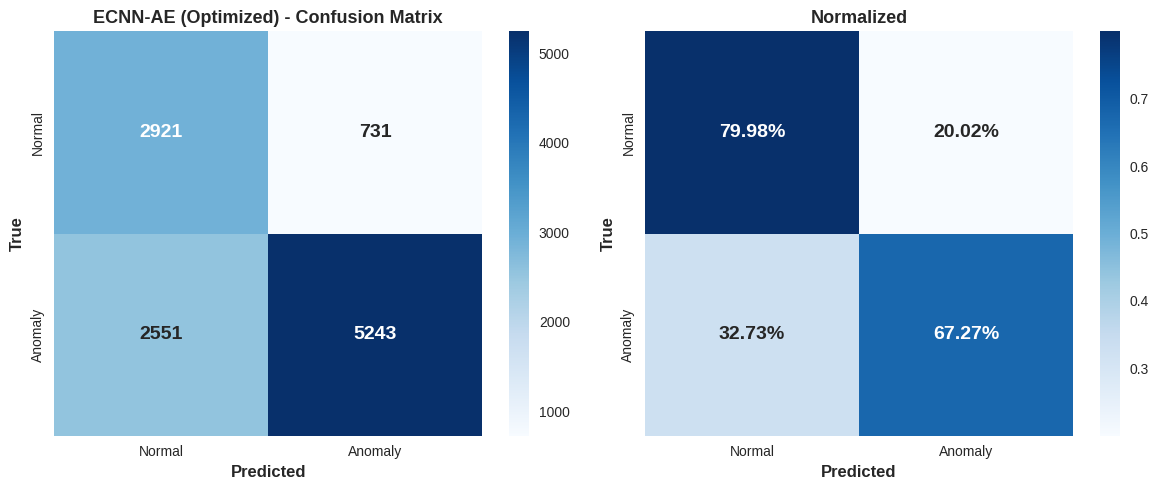

Confusion matrix saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/ecnn_opt_confusion_matrix.png

=== Evaluating: CNN-AE Large ===


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

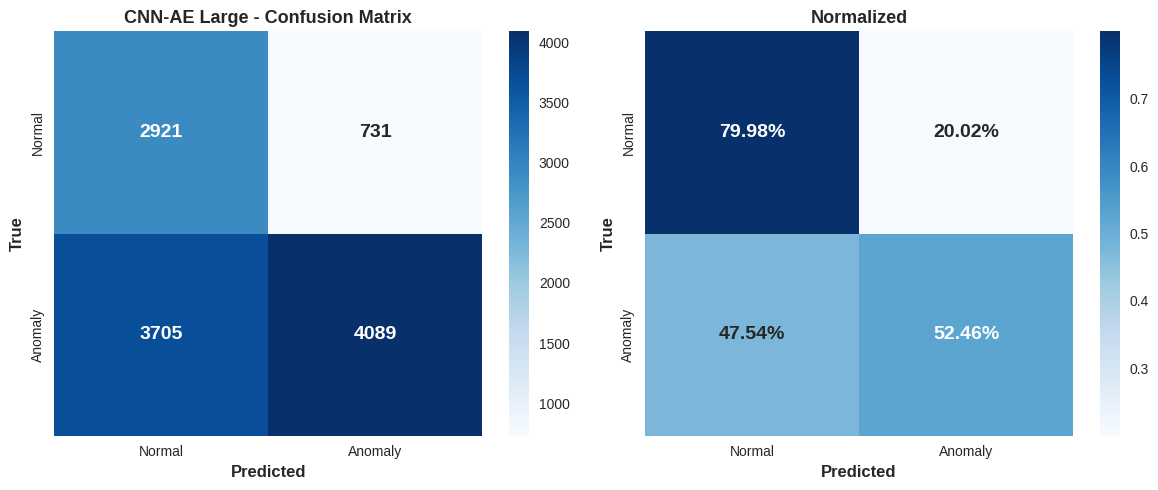

Confusion matrix saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/cnn_large_confusion_matrix.png

=== Evaluating: CNN-AE Augmented ===


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

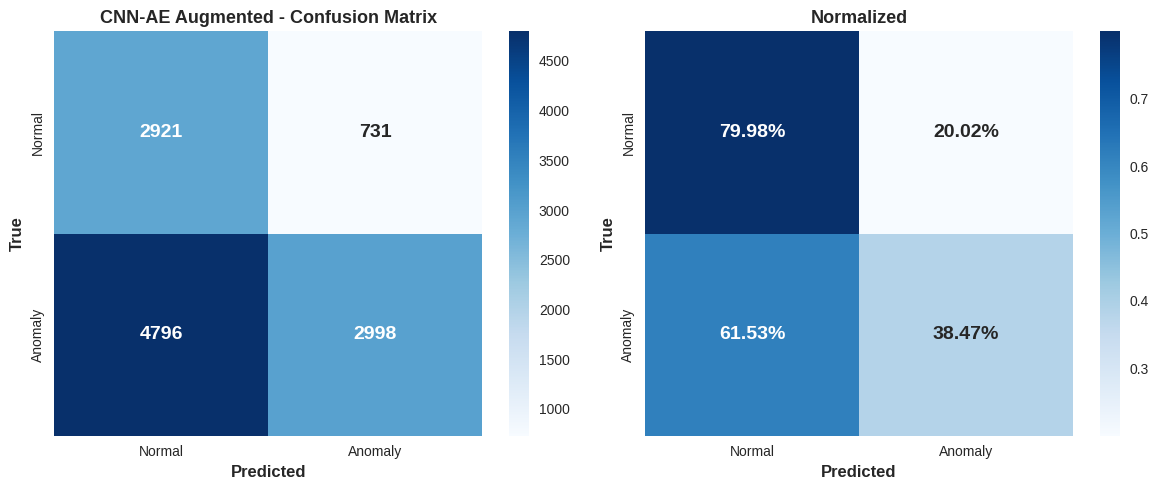

Confusion matrix saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/cnn_aug_confusion_matrix.png

=== Evaluating: CNN-AE ===


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

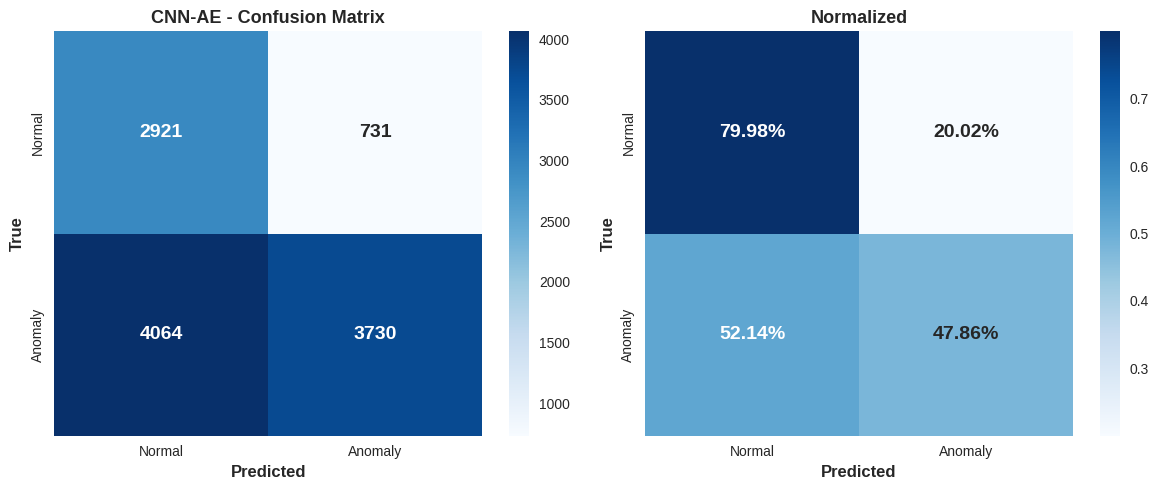

Confusion matrix saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/cnn_base_confusion_matrix.png

=== Evaluating: ResNet-AE ===


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

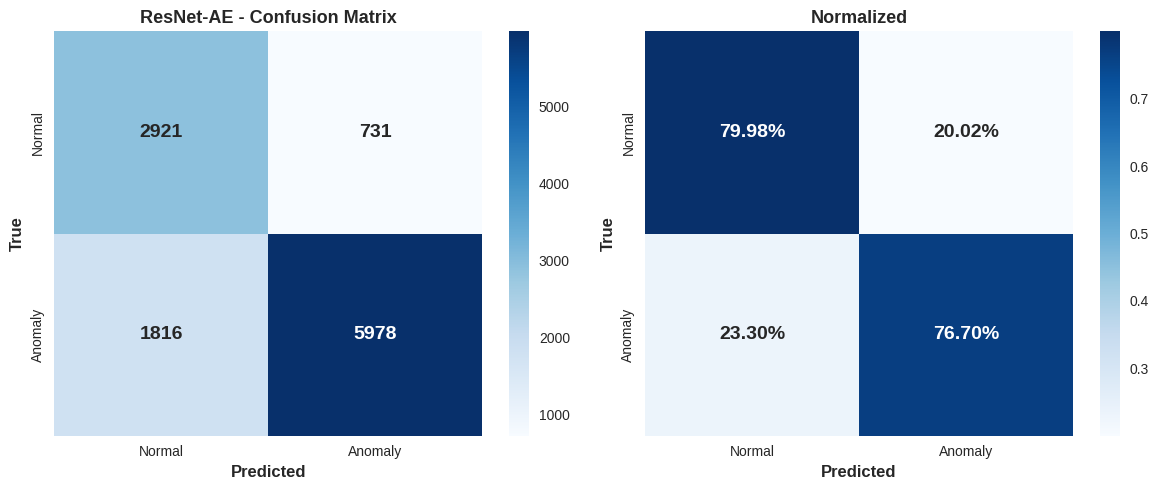

Confusion matrix saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/resnet_ae_confusion_matrix.png

=== Evaluating: ResNet-AE Finetuned (partial) ===


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

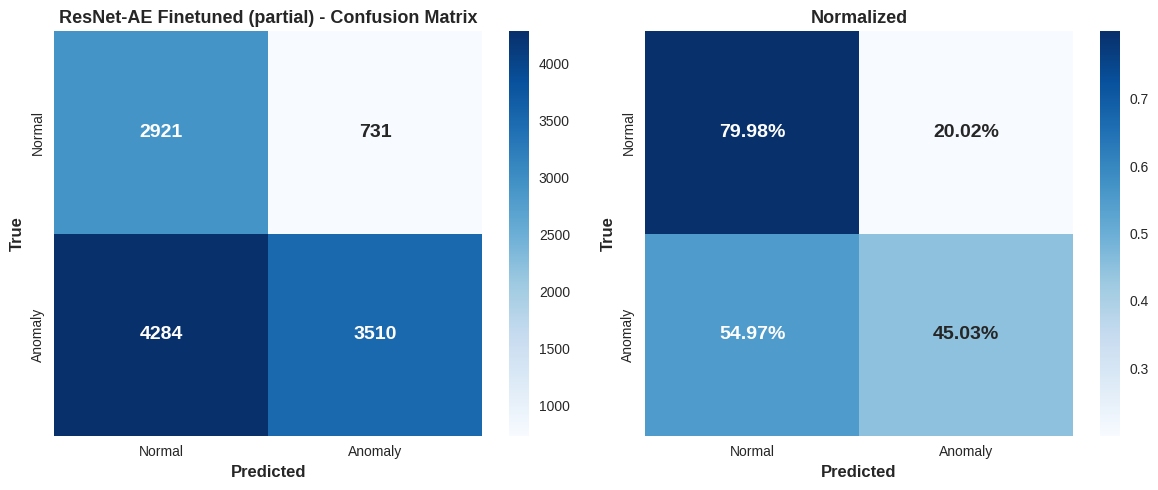

Confusion matrix saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/resnet_ft_confusion_matrix.png

Primary evaluation run complete.


In [5]:
# Run primary evaluation for all models (same turbo loader flow as training notebook)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

check_turbo_zips(ZIPS)

print('Extracting turbo datasets to local disk...')
for split, zip_path in ZIPS.items():
    target_dir = LOCAL_DIR / split
    extract_zip(zip_path, target_dir)
    print(f'  {split}: {zip_path} -> {target_dir}')

train_files = find_files(IXI_TRAIN_PATH)
normal_files = find_files(IXI_VAL_PATH)
anomaly_files = find_files(BRATS_PATH)

print(f'Train files (IXI train): {len(train_files)}')
print(f'Normal files (IXI val): {len(normal_files)}')
print(f'Anomaly files (BraTS test): {len(anomaly_files)}')
if len(normal_files) == 0 or len(anomaly_files) == 0:
    raise RuntimeError('No data files found after extraction. Check zip contents.')

rows = []
roc_payload = []

for cfg in MODEL_CONFIGS:
    print(f"\n=== Evaluating: {cfg['display_name']} ===")

    model, ckpt_path = load_model_for_config(cfg, device)
    mode = 'resnet' if 'resnet' in cfg['model_type'] else 'grayscale'

    normal_ds = SliceDataset(normal_files, mode=mode)
    anomaly_ds = SliceDataset(anomaly_files, mode=mode)

    normal_loader = DataLoader(normal_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    anomaly_loader = DataLoader(anomaly_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    normal_scores = compute_errors(
        model, normal_loader, device,
        use_brain_mask=USE_BRAIN_MASK_FOR_SCORING,
        min_brain_pixels=MIN_BRAIN_PIXELS,
        error_mode=FIXED_ERROR_MODE,
    )
    anomaly_scores = compute_errors(
        model, anomaly_loader, device,
        use_brain_mask=USE_BRAIN_MASK_FOR_SCORING,
        min_brain_pixels=MIN_BRAIN_PIXELS,
        error_mode=FIXED_ERROR_MODE,
    )

    threshold = threshold_from_normal_scores(normal_scores, target_fpr=TARGET_FPR)

    y_true = np.concatenate([np.zeros(len(normal_scores), dtype=int), np.ones(len(anomaly_scores), dtype=int)])
    y_scores = np.concatenate([normal_scores, anomaly_scores])

    metrics = compute_full_metrics(y_true, y_scores, threshold)
    y_pred = (y_scores >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # Confusion Matrix Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
    axes[0].set_title(f"{cfg['display_name']} - Confusion Matrix", fontsize=13, fontweight='bold')

    cm_norm = cm.astype('float') / np.clip(cm.sum(axis=1)[:, np.newaxis], a_min=1, a_max=None)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True', fontsize=12, fontweight='bold')
    axes[1].set_title('Normalized', fontsize=13, fontweight='bold')

    plt.tight_layout()
    cm_path = FIG_DIR / f"{cfg['key']}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f'Confusion matrix saved: {cm_path}')

    fpr_vals, tpr_vals, _ = roc_curve(y_true, y_scores)
    roc_payload.append({
        'model_name': cfg['display_name'],
        'fpr': fpr_vals,
        'tpr': tpr_vals,
        'auroc': float(metrics['auroc']),
    })

    row = {
        'model_key': cfg['key'],
        'model_name': cfg['display_name'],
        'checkpoint_path': str(ckpt_path),
        'score_method': TARGET_SCORE_METHOD,
        'threshold_method': 'fpr',
        'target_fpr': TARGET_FPR,
        'batch_size': int(TARGET_BATCH_SIZE),
        'error_mode': FIXED_ERROR_MODE,
        'use_brain_mask_for_scoring': bool(USE_BRAIN_MASK_FOR_SCORING),
        'min_brain_pixels': int(MIN_BRAIN_PIXELS),
        'threshold': float(threshold),
        'accuracy': float(metrics['accuracy']),
        'precision': float(metrics['precision']),
        'recall': float(metrics['recall']),
        'specificity': float(metrics['specificity']),
        'f1_score': float(metrics['f1_score']),
        'auroc': float(metrics['auroc']),
        'auprc': float(metrics['auprc']),
        'tp': int(metrics['tp']),
        'tn': int(metrics['tn']),
        'fp': int(metrics['fp']),
        'fn': int(metrics['fn']),
        'fpr': float(metrics['fpr']),
        'fnr': float(metrics['fnr']),
        'total_samples': int(metrics['total_samples']),
        'total_positive': int(metrics['total_positive']),
        'total_negative': int(metrics['total_negative']),
        'normal_count': int(len(normal_scores)),
        'anomaly_count': int(len(anomaly_scores)),
        'normal_mean': float(np.mean(normal_scores)),
        'normal_std': float(np.std(normal_scores)),
        'anomaly_mean': float(np.mean(anomaly_scores)),
        'anomaly_std': float(np.std(anomaly_scores)),
    }
    rows.append(row)

    np.save(JSON_DIR / f"{cfg['key']}_normal_scores.npy", normal_scores)
    np.save(JSON_DIR / f"{cfg['key']}_anomaly_scores.npy", anomaly_scores)

print('\nPrimary evaluation run complete.')

In [6]:
# Save consolidated tables and rankings
if not rows:
    raise RuntimeError('No model results collected.')

df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)

display_cols = [
    'model_name', 'score_method', 'threshold_method', 'target_fpr', 'threshold',
    'accuracy', 'precision', 'recall', 'specificity', 'f1_score', 'auroc', 'auprc',
    'tp', 'tn', 'fp', 'fn', 'total_samples', 'total_positive', 'total_negative'
]
display(df[display_cols])

csv_path = TABLE_DIR / 'primary_mean_fpr20_metrics.csv'
md_path = TABLE_DIR / 'primary_mean_fpr20_metrics.md'
json_path = JSON_DIR / 'primary_mean_fpr20_metrics.json'

df.to_csv(csv_path, index=False)
df.to_markdown(md_path, index=False)
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(rows, f, indent=2)

best_path = TABLE_DIR / 'primary_mean_fpr20_best_model.txt'
best = df.iloc[0]
with open(best_path, 'w', encoding='utf-8') as f:
    f.write('Primary Evaluation (mean + fpr@0.20)\n')
    f.write(f"Best model by AUROC: {best['model_name']}\n")
    f.write(f"AUROC={best['auroc']:.4f}, AUPRC={best['auprc']:.4f}, F1={best['f1_score']:.4f}, Recall={best['recall']:.4f}, Specificity={best['specificity']:.4f}\n")

print(f'CSV saved: {csv_path}')
print(f'Markdown saved: {md_path}')
print(f'JSON saved: {json_path}')
print(f'Best-model note saved: {best_path}')

,model_name,score_method,threshold_method,target_fpr,threshold,accuracy,precision,recall,specificity,f1_score,auroc,auprc,tp,tn,fp,fn,total_samples,total_positive,total_negative
0,ResNet-AE,mean,fpr,0.2,0.012338,0.777477,0.891042,0.767000,0.799836,0.824381,0.874818,0.932574,5978,2921,731,1816,11446,7794,3652
1,ECNN-AE (Optimized),mean,fpr,0.2,0.003097,0.713262,0.877636,0.672697,0.799836,0.761621,0.842363,0.902753,5243,2921,731,2551,11446,7794,3652
2,CNN-AE Large,mean,fpr,0.2,0.006904,0.612441,0.848340,0.524634,0.799836,0.648327,0.780265,0.858938,4089,2921,731,3705,11446,7794,3652
3,CNN-AE,mean,fpr,0.2,0.007245,0.581076,0.836135,0.478573,0.799836,0.608731,0.761681,0.847924,3730,2921,731,4064,11446,7794,3652
4,ResNet-AE Finetuned (partial),mean,fpr,0.2,0.008822,0.561856,0.827635,0.450346,0.799836,0.583299,0.739819,0.835497,3510,2921,731,4284,11446,7794,3652
5,CNN-AE Augmented,mean,fpr,0.2,0.008570,0.517124,0.803969,0.384655,0.799836,0.520351,0.707196,0.802344,2998,2921,731,4796,11446,7794,3652


CSV saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/primary_mean_fpr20/primary_mean_fpr20_metrics.csv
Markdown saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/primary_mean_fpr20/primary_mean_fpr20_metrics.md
JSON saved: /content/drive/MyDrive/symAD-ECNN/evaluations/json/primary_mean_fpr20/primary_mean_fpr20_metrics.json
Best-model note saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/primary_mean_fpr20/primary_mean_fpr20_best_model.txt


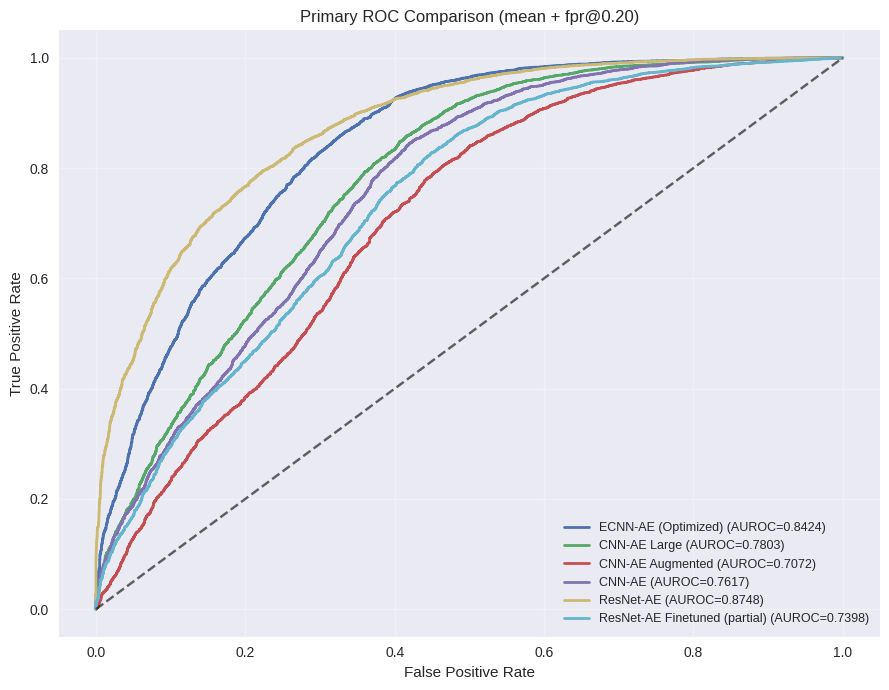

Combined ROC saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/primary_mean_fpr20_roc_comparison.png


In [7]:
# Combined ROC plot for all models
plt.figure(figsize=(9, 7))
for item in roc_payload:
    plt.plot(item['fpr'], item['tpr'], linewidth=2, label=f"{item['model_name']} (AUROC={item['auroc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Primary ROC Comparison (mean + fpr@0.20)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
roc_path = FIG_DIR / 'primary_mean_fpr20_roc_comparison.png'
plt.savefig(roc_path, dpi=150)
plt.show()
print(f'Combined ROC saved: {roc_path}')

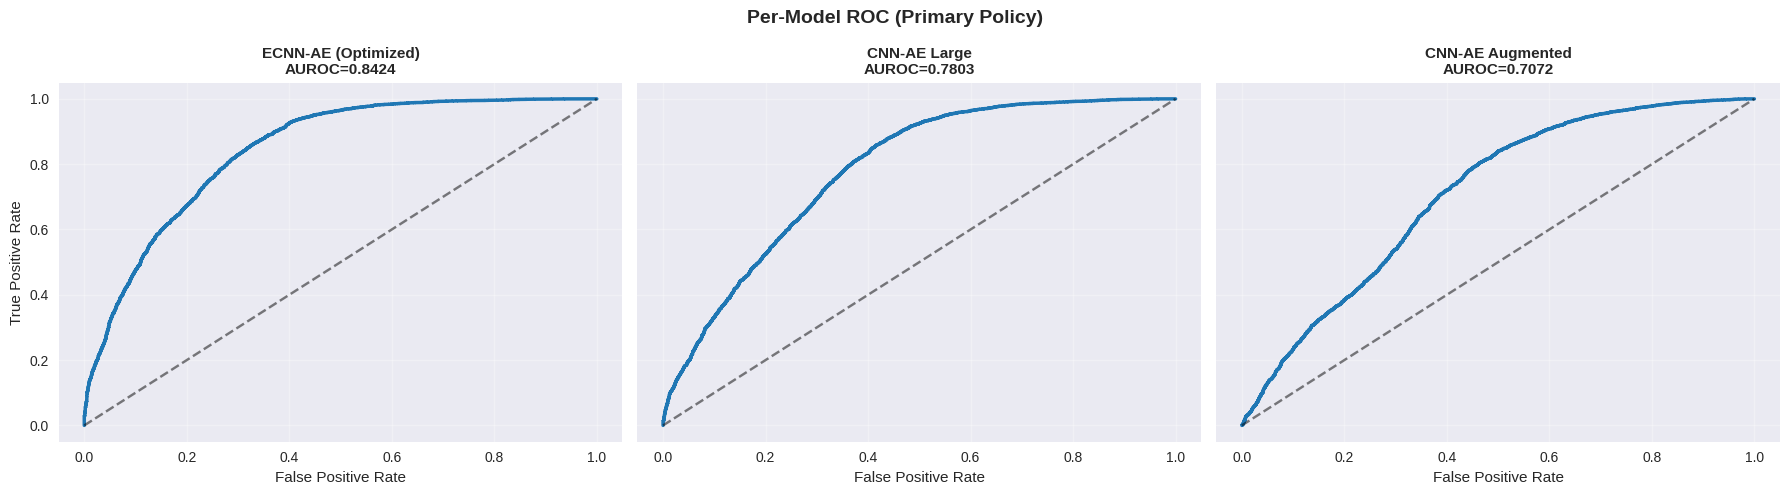

Selected ROC row saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/primary_mean_fpr20/primary_mean_fpr20_roc_selected_row.png


In [8]:
# Separate ROC panels (1x3) for selected models
selected_models = [
    'ECNN-AE (Optimized)',
    'CNN-AE Large',
    'CNN-AE Augmented',
]

if not roc_payload:
    print('No ROC payload found. Run the evaluation cell first.')
else:
    payload_by_name = {item['model_name']: item for item in roc_payload}
    missing = [name for name in selected_models if name not in payload_by_name]

    if missing:
        print('Missing ROC entries for:', ', '.join(missing))
        print('Available models:', ', '.join(payload_by_name.keys()))
    else:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

        for ax, model_name in zip(axes, selected_models):
            item = payload_by_name[model_name]
            ax.plot(item['fpr'], item['tpr'], linewidth=2.5, color='tab:blue')
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
            ax.set_title(f"{model_name}\nAUROC={item['auroc']:.4f}", fontsize=11, fontweight='bold')
            ax.set_xlabel('False Positive Rate')
            ax.grid(alpha=0.3)

        axes[0].set_ylabel('True Positive Rate')
        fig.suptitle('Per-Model ROC (Primary Policy)', fontsize=14, fontweight='bold')
        plt.tight_layout()

        roc_selected_path = FIG_DIR / 'primary_mean_fpr20_roc_selected_row.png'
        plt.savefig(roc_selected_path, dpi=150)
        plt.show()
        print(f'Selected ROC row saved: {roc_selected_path}')

## Done
This notebook is now your organized **primary evaluation** pipeline with a fixed and consistent thresholding policy (**mean + FPR 20%**), full classification metrics, totals, and saved confusion matrix visualizations for each model.